# Notebook 02 — Error Analysis

This notebook:
- Loads the baseline model and test data produced by Notebook 01
- Identifies misclassified samples (the model's failure modes)
- Segments errors by feature groups (class, sex, age band, fare band)
- Computes per-cohort **recall** to locate the worst-performing segments
- Saves `target_cohorts.json` for synthetic generation in Notebook 03

In [1]:
import sys, warnings, json
warnings.filterwarnings('ignore')
sys.path.insert(0, '.')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from models_utils import load_model, evaluate_performance

%matplotlib inline
print('Imports OK')

Imports OK


## 1. Load Artefacts from Notebook 01

In [2]:
# Load baseline model and preprocessor
baseline_model = load_model('artifacts/baseline_rf_model.pkl')
preprocessor   = joblib.load('artifacts/preprocessor.pkl')

# Load cleaned data splits (raw, un-scaled)
X_train = pd.read_csv('artifacts/X_train_clean.csv')
X_test  = pd.read_csv('artifacts/X_test_clean.csv')
y_train = pd.read_csv('artifacts/y_train_clean.csv').squeeze()
y_test  = pd.read_csv('artifacts/y_test_clean.csv').squeeze()

# Preprocessed test set for evaluation 
X_test_proc = preprocessor.transform(X_test)

print(f'Test samples: {len(X_test)}')
print(f'Baseline AUC confirmation:')
_ = evaluate_performance(baseline_model, X_test_proc, y_test, verbose=True)

[model_utils] Model loaded <- artifacts/baseline_rf_model.pkl


Test samples: 800
Baseline AUC confirmation:


[model_utils] Evaluation results:
  accuracy    : 0.9563
  precision   : 1.0000
  recall      : 0.2045
  f1          : 0.3396
  roc_auc     : 0.8950

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       756
           1       1.00      0.20      0.34        44

    accuracy                           0.96       800
   macro avg       0.98      0.60      0.66       800
weighted avg       0.96      0.96      0.94       800



## 2. Identify Misclassified Samples

In [3]:
y_pred = baseline_model.predict(X_test_proc)
y_prob = baseline_model.predict_proba(X_test_proc)[:, 1]

# Attach predictions and raw features to one DataFrame
error_df = X_test.copy()
error_df['is_fraud']    = y_test.values
error_df['predicted']   = y_pred
error_df['probability'] = y_prob
error_df['error']       = (y_test.values != y_pred).astype(int)

print(f'Total test samples      : {len(error_df)}')
print(f'Correctly classified    : {(error_df["error"] == 0).sum()}')
print(f'Misclassified           : {(error_df["error"] == 1).sum()} ({error_df["error"].mean()*100:.1f}%)')
print(f'\nError type breakdown:')
print(f'  False Negatives (missed fraud_cases) : {((error_df["is_fraud"]==1) & (error_df["error"]==1)).sum()}')
print(f'  False Positives (false alarms)     : {((error_df["is_fraud"]==0) & (error_df["error"]==1)).sum()}')

Total test samples      : 800
Correctly classified    : 765
Misclassified           : 35 (4.4%)

Error type breakdown:
  False Negatives (missed fraud_cases) : 35
  False Positives (false alarms)     : 0


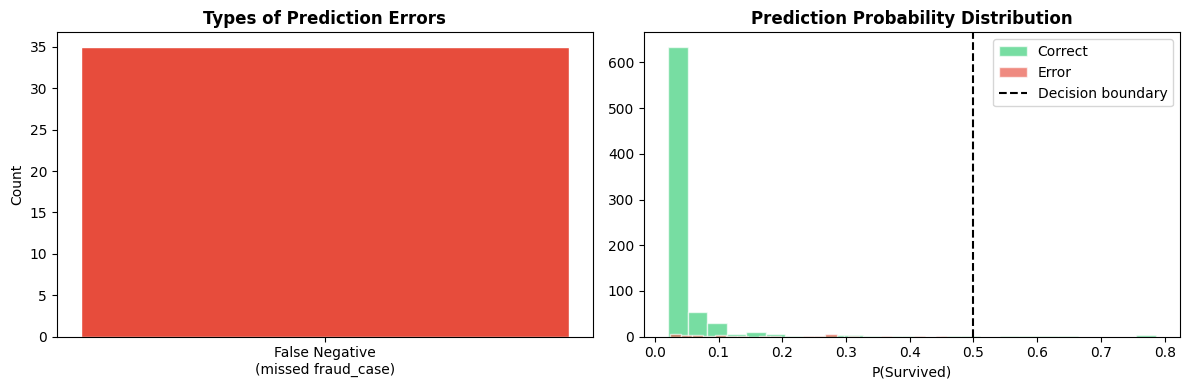

In [4]:
# --- Visualise error distribution ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

error_types = error_df[error_df['error'] == 1].copy()
error_types['error_type'] = error_types.apply(
    lambda r: 'False Negative\n(missed fraud_case)'
              if r['is_fraud'] == 1 else 'False Positive\n(false alarm)', axis=1
)
v_counts = error_types['error_type'].value_counts()
axes[0].bar(v_counts.index, v_counts.values, color=['#e74c3c', '#f39c12'], edgecolor='white')
axes[0].set_title('Types of Prediction Errors', fontweight='bold')
axes[0].set_ylabel('Count')

# Probability histogram for errors
axes[1].hist(error_df[error_df['error']==0]['probability'], bins=25, alpha=0.65,
             label='Correct', color='#2ecc71', edgecolor='white')
axes[1].hist(error_df[error_df['error']==1]['probability'], bins=25, alpha=0.65,
             label='Error', color='#e74c3c', edgecolor='white')
axes[1].axvline(0.5, color='black', linestyle='--', linewidth=1.5, label='Decision boundary')
axes[1].set_title('Prediction Probability Distribution', fontweight='bold')
axes[1].set_xlabel('P(Survived)')
axes[1].legend()

plt.tight_layout()
plt.savefig('artifacts/error_analysis_overview.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Cohort-Level Recall Analysis

We slice the test set into meaningful cohorts and compute recall (True Positive Rate) for the minority class (is_fraud=1). Low recall = model struggles to identify fraud_cases in this cohort.

In [5]:
def cohort_recall(df, group_col, target='target_col', predicted='predicted'):
    """
    Compute recall (TP / (TP + FN)) for the minority class=1
    within each group defined by group_col.
    """
    results = []
    for grp_val, grp in df.groupby(group_col):
        positives  = grp[grp[target] == 1]
        n_pos      = len(positives)
        n_correct  = (positives[predicted] == 1).sum()
        n_errors   = (positives[predicted] == 0).sum()
        recall_val = n_correct / n_pos if n_pos > 0 else np.nan
        results.append({
            'group_col': group_col,
            'group_val': grp_val,
            'n_target_cases': n_pos,
            'tp': n_correct,
            'fn': n_errors,
            'recall': recall_val,
        })
    return pd.DataFrame(results)

target_col_name = y_test.name

# Add derived grouping columns dynamically from the first 5 columns of test set
cohort_dfs = []
cols_to_check = list(X_test.columns)[:min(5, len(X_test.columns))]

for col in cols_to_check:
    if pd.api.types.is_numeric_dtype(X_test[col]) and X_test[col].nunique() > 10:
        # Bin it into quartiles dynamically
        group_name = f'{col}_band'
        error_df[group_name] = pd.qcut(error_df[col], q=4, duplicates='drop')
        cohort_dfs.append(cohort_recall(error_df, group_name, target=target_col_name))
    else:
        cohort_dfs.append(cohort_recall(error_df, col, target=target_col_name))

if cohort_dfs:
    cohort_results = pd.concat(cohort_dfs, ignore_index=True)
    cohort_results = cohort_results.sort_values('recall').dropna()
    print(cohort_results.to_string(index=False))
else:
    print("Could not generate cohorts.")

     group_col                      group_val  n_target_cases  tp  fn   recall
feature_1_band              (-1.115, -0.0944]               8   0   8 0.000000
feature_1_band                (-4.32, -1.115]               2   0   2 0.000000
feature_3_band                 (1.696, 5.578]               3   0   3 0.000000
feature_3_band                 (0.948, 1.696]               3   0   3 0.000000
feature_3_band               (-0.0212, 0.948]               8   0   8 0.000000
feature_4_band               (-3.733, -0.645]              17   1  16 0.058824
feature_0_band  (-3.3049999999999997, -0.672]              10   1   9 0.100000
feature_2_band               (-0.685, 0.0423]               9   1   8 0.111111
feature_2_band                 (0.725, 2.847]               7   1   6 0.142857
feature_4_band                 (0.654, 2.939]               6   1   5 0.166667
feature_0_band                 (0.669, 4.817]              15   3  12 0.200000
feature_2_band  (-2.8979999999999997, -0.685]       

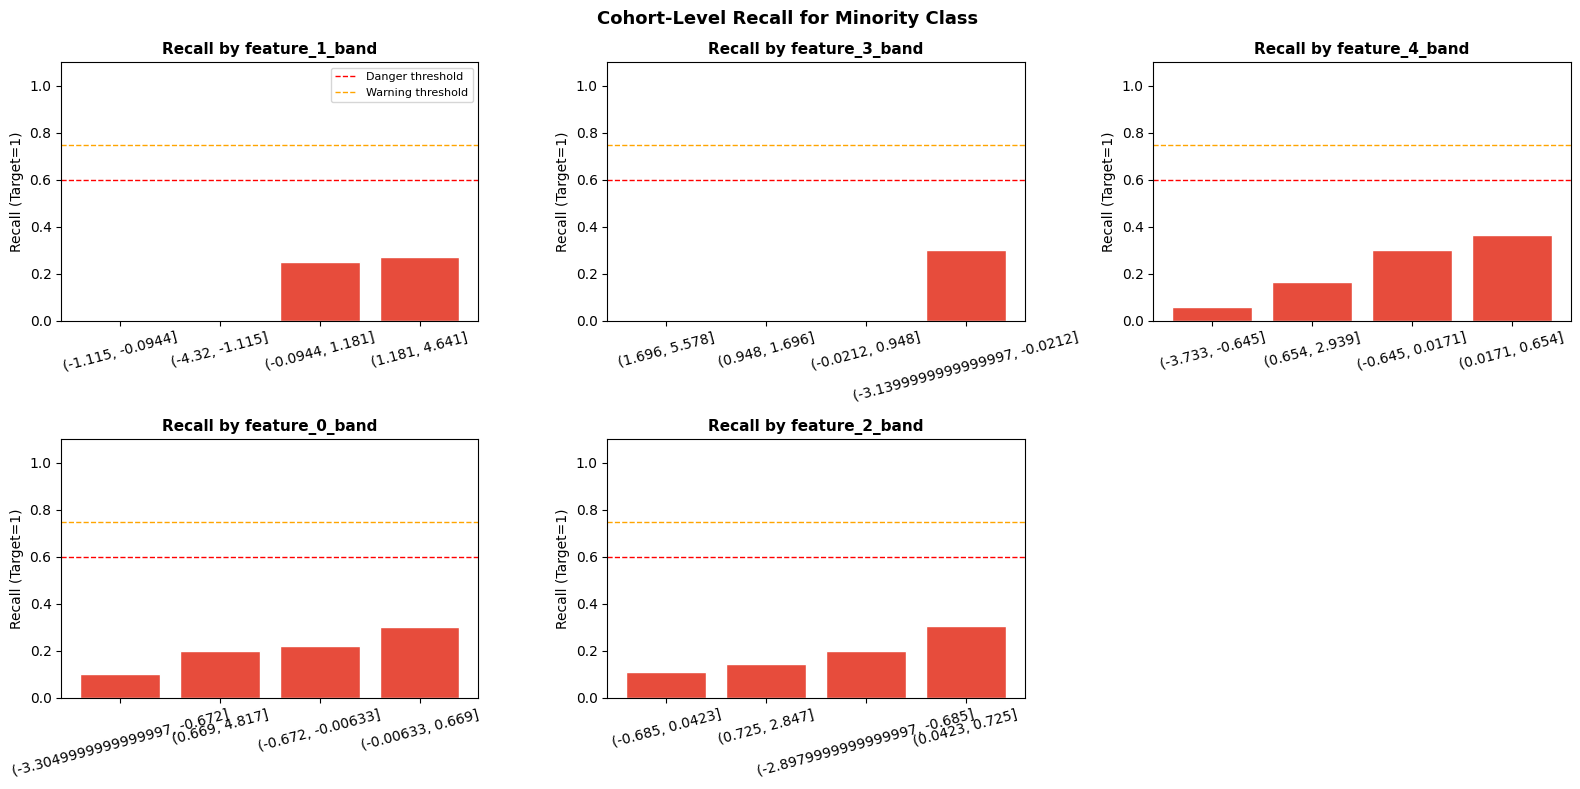

In [6]:
# --- Visualise cohort recalls ---
if 'cohort_results' in locals() and not cohort_results.empty:
    unique_groups = cohort_results['group_col'].unique()
    fig, axes = plt.subplots(int(np.ceil(len(unique_groups)/3)), 3, figsize=(16, 8))
    if type(axes) == np.ndarray: axes = axes.flatten()
    else: axes = [axes]

    for i, col in enumerate(unique_groups):
        subset = cohort_results[cohort_results['group_col'] == col].sort_values('recall')
        colors = ['#e74c3c' if r < 0.6 else '#f39c12' if r < 0.75 else '#2ecc71' for r in subset['recall']]
        axes[i].bar(subset['group_val'].astype(str), subset['recall'], color=colors, edgecolor='white')
        axes[i].axhline(0.6, color='red',   linestyle='--', linewidth=1, label='Danger threshold')
        axes[i].axhline(0.75, color='orange', linestyle='--', linewidth=1, label='Warning threshold')
        axes[i].set_title(f'Recall by {col}', fontsize=11, fontweight='bold')
        axes[i].set_ylabel('Recall (Target=1)')
        axes[i].set_ylim(0, 1.1)
        axes[i].tick_params(axis='x', rotation=15)
        if i == 0: axes[i].legend(fontsize=8)

    for j in range(len(unique_groups), len(axes)):
        axes[j].axis('off')
        
    plt.suptitle('Cohort-Level Recall for Minority Class', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('artifacts/error_analysis_cohort_recall.png', dpi=150, bbox_inches='tight')
    plt.show()

## 4. Select Target Cohorts (Weakest Performers)

In [7]:
# Select cohorts with recall < 0.75 and at least 3 target_cases in test
weak_cohorts = cohort_results[
    (cohort_results['recall'] < 0.75) & (cohort_results['n_target_cases'] >= 3)
].copy()

print(f'Identified {len(weak_cohorts)} weak cohorts:')
print(weak_cohorts[['group_col', 'group_val', 'n_target_cases', 'recall']].to_string(index=False))

Identified 19 weak cohorts:
     group_col                      group_val  n_target_cases   recall
feature_1_band              (-1.115, -0.0944]               8 0.000000
feature_3_band                 (1.696, 5.578]               3 0.000000
feature_3_band                 (0.948, 1.696]               3 0.000000
feature_3_band               (-0.0212, 0.948]               8 0.000000
feature_4_band               (-3.733, -0.645]              17 0.058824
feature_0_band  (-3.3049999999999997, -0.672]              10 0.100000
feature_2_band               (-0.685, 0.0423]               9 0.111111
feature_2_band                 (0.725, 2.847]               7 0.142857
feature_4_band                 (0.654, 2.939]               6 0.166667
feature_0_band                 (0.669, 4.817]              15 0.200000
feature_2_band  (-2.8979999999999997, -0.685]              15 0.200000
feature_0_band             (-0.672, -0.00633]               9 0.222222
feature_1_band               (-0.0944, 1.181]    

In [8]:
# Build structured JSON for notebook 03
target_cohorts = []
for _, row in weak_cohorts.iterrows():
    col, val = row['group_col'], row['group_val']
    
    # Generic logic for pd.Interval (created by pd.qcut)
    if str(col).endswith('_band'):
        orig_col = str(col).replace('_band', '')
        low, high = val.left, val.right
        conditions = {f'{orig_col}_low': low, f'{orig_col}_high': high}
        cohort_type = 'range'
        group_col_name = orig_col
    else:
        conditions = {str(col): val}
        cohort_type = 'equality'
        group_col_name = str(col)
    
    target_cohorts.append({
        'name': f'{col}={val}',
        'group_col': group_col_name,
        'group_val': str(val),
        'cohort_type': cohort_type,
        'conditions': conditions,
        'label': 1,  # we want to oversample minority in weak areas
        'recall': round(float(row['recall']), 4),
        'n_target_cases_in_test': int(row['n_target_cases']),
    })

print(f'\nTarget cohorts JSON ({len(target_cohorts)} entries):')
for c in target_cohorts:
    print(f"  {c['name']:25s}  recall={c['recall']:.3f}")


Target cohorts JSON (19 entries):
  feature_1_band=(-1.115, -0.0944]  recall=0.000
  feature_3_band=(1.696, 5.578]  recall=0.000
  feature_3_band=(0.948, 1.696]  recall=0.000
  feature_3_band=(-0.0212, 0.948]  recall=0.000
  feature_4_band=(-3.733, -0.645]  recall=0.059
  feature_0_band=(-3.3049999999999997, -0.672]  recall=0.100
  feature_2_band=(-0.685, 0.0423]  recall=0.111
  feature_2_band=(0.725, 2.847]  recall=0.143
  feature_4_band=(0.654, 2.939]  recall=0.167
  feature_0_band=(0.669, 4.817]  recall=0.200
  feature_2_band=(-2.8979999999999997, -0.685]  recall=0.200
  feature_0_band=(-0.672, -0.00633]  recall=0.222
  feature_1_band=(-0.0944, 1.181]  recall=0.250
  feature_1_band=(1.181, 4.641]  recall=0.273
  feature_0_band=(-0.00633, 0.669]  recall=0.300
  feature_4_band=(-0.645, 0.0171]  recall=0.300
  feature_3_band=(-3.1399999999999997, -0.0212]  recall=0.300
  feature_2_band=(0.0423, 0.725]  recall=0.308
  feature_4_band=(0.0171, 0.654]  recall=0.364


In [9]:
# Save target_cohorts.json
with open('artifacts/target_cohorts.json', 'w') as f:
    json.dump(target_cohorts, f, indent=2, default=str)

print('target_cohorts.json saved → artifacts/target_cohorts.json')
print(json.dumps(target_cohorts[:2], indent=2, default=str))

target_cohorts.json saved → artifacts/target_cohorts.json
[
  {
    "name": "feature_1_band=(-1.115, -0.0944]",
    "group_col": "feature_1",
    "group_val": "(-1.115, -0.0944]",
    "cohort_type": "range",
    "conditions": {
      "feature_1_low": -1.115,
      "feature_1_high": -0.0944
    },
    "label": 1,
    "recall": 0.0,
    "n_target_cases_in_test": 8
  },
  {
    "name": "feature_3_band=(1.696, 5.578]",
    "group_col": "feature_3",
    "group_val": "(1.696, 5.578]",
    "cohort_type": "range",
    "conditions": {
      "feature_3_low": 1.696,
      "feature_3_high": 5.578
    },
    "label": 1,
    "recall": 0.0,
    "n_target_cases_in_test": 3
  }
]
